<h1 style="text-align: center;"><b>EXPLORATORY DATA ANALYSIS (EDA)</b></h1>

##### Exploring the Texas Department of Family and Protective Services(DFPS) Child Protective Services(CPS) Removals by Region dataset from Fiscal Years (FY) 2016 to 2025.

### created by ***Ashley Hendrix***

### **Libraries/Packages** used in this data analysis

- **Pandas** for data analysis,data manipuation and data cleaning
- **Numpy** for scientific computing, data science, and mathematical operations
- **MatplotLib** for creating data visulazations 
- **Plotly** for browser based data visualization tool for interactve visuals

In [1]:
# Libraries and Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

plt.style.use("ggplot")

### **Dataset Description and Preview**

**CPS 2.1 Removals - by Region with Child Demographics FY2016-2025**
According to the [TX DFPS Data and Decision Support](https://data.texas.gov/dataset/CPS-2-1-Removals-by-Region-with-Child-Demographics/izsm-24wy/about_data).

This dataset shows the data for CPS removals "a removal occurs when CPS determines that a child cannot safely remain in their own home and that DFPS needs to seek legal custody to ensure child safety. Removals can occur in an investigation, family preservation, family substitute care or family reunification stage."


In [2]:
# load dataset
df = pd.read_excel("CPS_2.1_Removals_by_Region_with_Child_Demographics_FY2016-2025.xlsx")

# preview the dataset
df.head()

,Fiscal Year,Region,Removal Stage,Sex,Race/Ethnicity,Age,Removals
0,2025,1-Lubbock,Family Preservation,Female,African American,0,1
1,2025,1-Lubbock,Family Preservation,Female,African American,1,2
2,2025,1-Lubbock,Family Preservation,Female,African American,2,1
3,2025,1-Lubbock,Family Preservation,Female,African American,3,0
4,2025,1-Lubbock,Family Preservation,Female,African American,4,0


### **Dataset Information**

This dataset has 7 columns
- Fiscal Year : *Texas DFPS fiscal year begins September 1st of the previous year and ends August 31st of the current year.*
    - **FY2016** (Sept. 1, 2015 - Aug 31,2016)
    - **FY2017** (Sept. 1, 2016 - Aug 31,2017) 
    - **FY2018** (Sept. 1, 2017 - Aug 31,2018) 
    - **FY2019** (Sept. 1, 2018 - Aug 31,2019) 
    - **FY2020** (Sept. 1, 2019 - Aug 31,2020) 
    - **FY2021** (Sept. 1, 2020 - Aug 31,2021)  
    - **FY2022** (Sept. 1, 2021 - Aug 31,2022) 
    - **FY2023** (Sept. 1, 2022 - Aug 31,2023) 
    - **FY2024** (Sept. 1, 2023 - Aug 31,2024) 
    - **FY2025** (Sept. 1, 2024 - Aug 31,2025) 
    
- Region : *There are 11 DFPS regions, there were some remvovals conducted out of state, and some where the region of the child is unknow to the reporter.*
    - **1-Lubbock**
    - **2-Abilene**
    - **3-Arlington**     
    - **4-Tyler**   
    - **5-Beaumont**   
    - **6-Houston**  
    - **7-Austin**    
    - **8-San Antonio**
    - **9-Midland**
    - **10-El Paso**
    - **11-Edinburg** 
    - **Unknown**
    - **Out of State**

- Removal Stage : *There are several stages in the CPS Program, the two that are represented in this dataset are as follows.* <br>
    - **Family Preservation** : Family Preservation Services (FPR) or Family Based Safety Services (FBSS), FBSS is under the umbrella of FPR. FPR are services provided to the child and the family by DFPS where the caregiver retains legal custody. According to [DFPS Data and Decision Support](https://data.texas.gov/dataset/CPS-1-3-FBSS-Children-Entering-Family-Preservation/2hki-6gbm/about_data)<br>
    - **Investigation** : The fact-finding phase where the state evalutes allegations of abuse, neglect or exploitation of a child under the age of 18 and not emancipated. This state comes after the intake has been assessed as meeting the guildlines of abuse, neglect or exploitation in the state of Texas, and is determined necessary by CPS staff in the region to which the report is assigned. 

- Sex : *"Sex means and individual's biological sex, either male or female. According to the [Texas Legislature House Bill No. 229.](https://capitol.texas.gov/tlodocs/89R/billtext/html/HB00229F.HTM)*
    - **Male** 
    - **Female** <br>



- Race/Ethnicity :
    - **African American**
    - **Anglo**
    - **Asian**
    - **Hispanic**
    - **Native American** 
    - **Other**
    
- Age : *For the purpose of an investigation a child must be born alive and be under the age of 18 at the time of intake, however there are some rare special circumstances that may be present for Child Protective Services to interviene on an indivitals behalf outside of those parameter. However for this dataset children are between the ages of 0 meaning live birth and under the age of 18.*

- Removals : *Represents the number of removals conducted for that specific fiscal year, region, removal stage, sex, race/ethnicity and age.*

In [3]:
# data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27438 entries, 0 to 27437
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Fiscal Year     27438 non-null  int64
 1   Region          27438 non-null  str  
 2   Removal Stage   27438 non-null  str  
 3   Sex             27438 non-null  str  
 4   Race/Ethnicity  27438 non-null  str  
 5   Age             27438 non-null  int64
 6   Removals        27438 non-null  int64
dtypes: int64(3), str(4)
memory usage: 2.5 MB


#### **Clean columns names**
***Standardizing column names for ease of use when calling and renameing***

In [4]:
# clean column names and format them
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

df.head()

,fiscal_year,region,removal_stage,sex,race/ethnicity,age,removals
0,2025,1-Lubbock,Family Preservation,Female,African American,0,1
1,2025,1-Lubbock,Family Preservation,Female,African American,1,2
2,2025,1-Lubbock,Family Preservation,Female,African American,2,1
3,2025,1-Lubbock,Family Preservation,Female,African American,3,0
4,2025,1-Lubbock,Family Preservation,Female,African American,4,0


### **Summary Statistics**
***Using the pandas describe method to view statistical data for each colunm's values.***

In [5]:
# Data statistics for numerical data 
df[["fiscal_year", "age", "removals"]].describe(include="all")


,fiscal_year,age,removals
count,27438.000000,27438.000000,27438.00000
mean,2020.357023,7.938479,5.45273
std,2.859024,5.157448,10.43550
min,2016.000000,0.000000,0.00000
25%,2018.000000,3.000000,1.00000
50%,2020.000000,8.000000,2.00000
75%,2023.000000,12.000000,6.00000
max,2025.000000,17.000000,192.00000


In [6]:
# Data statistics for categorical data

df[["region", "race/ethnicity","sex", "region"]].describe()


,region,race/ethnicity,sex,region
count,27438,27438,27438,27438
unique,13,6,3,13
top,3-Arlington,Hispanic,Female,3-Arlington
freq,3212,7652,13776,3212


### **Missing values**

In [7]:
# missing values in dataset

df.isnull().sum()

fiscal_year       0
region            0
removal_stage     0
sex               0
race/ethnicity    0
age               0
removals          0
dtype: int64

###  ***Univariate Analysis*** 
*A simple statistical data analysis that examines each variable (var) independently to understand its value distribution.*

#### **Numeric Variables**
**Fiscal Year**
The distribution of Fiscal Year shows how case counts vary across reporting years. This helps identify trends in removals over time, such as increases or decreases in workload or policy‑driven changes.

**Age**
The Age distribution highlights the age ranges most commonly represented in the dataset. This can reveal concentration around certain age groups, potential outliers, and demographic patterns relevant to DFPS casework.

**Removals**
The Removals variable shows how many removals occurred per record. Understanding this distribution helps identify whether removals are typically single‑event cases or whether multiple removals occur within the same reporting unit.

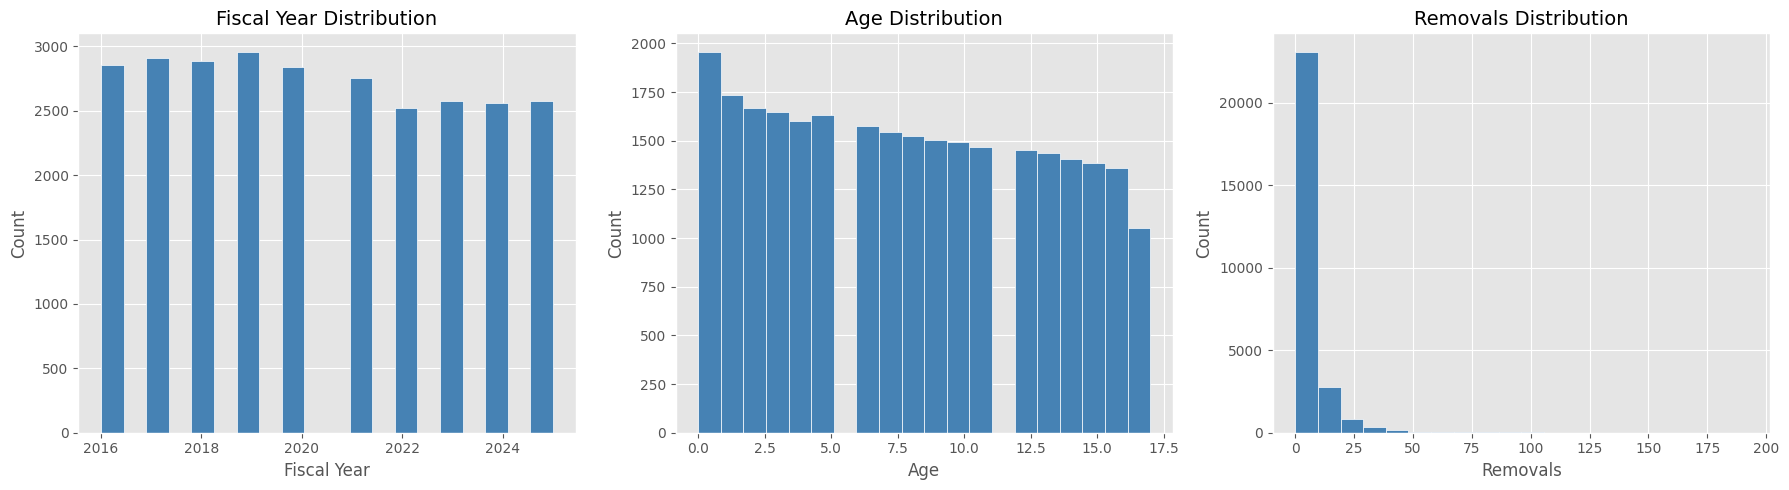

In [8]:
# Distribution of Fiscal Year, Age and Removals
plt.figure(figsize=(18, 5))

# Fiscal Year
plt.subplot(1, 3, 1)
plt.hist(df['fiscal_year'], bins=20, color='steelblue', edgecolor='white')
plt.title('Fiscal Year Distribution', fontsize=14)
plt.xlabel('Fiscal Year')
plt.ylabel('Count')

# Age
plt.subplot(1, 3, 2)
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')

# Removals
plt.subplot(1, 3, 3)
plt.hist(df['removals'], bins=20, color='steelblue', edgecolor='white')
plt.title('Removals Distribution', fontsize=14)
plt.xlabel('Removals')
plt.ylabel('Count')

plt.tight_layout()
plt.show()



#### **Categorical Variables**
**Region**
The Region variable shows how cases are distributed geographically across DFPS service regions. This helps identify regional workload differences and potential hotspots.

**Removal Stage**
The Removal Stage distribution highlights the point in the process where removals occur. This can reveal whether most removals happen early, during investigation, or later in the case lifecycle.

**Sex**
The Sex distribution provides insight into gender representation within the dataset. This helps identify demographic patterns and potential disparities.

**Race/Ethnicity**
The Race/Ethnicity variable shows the demographic composition of individuals represented in the dataset. This is essential for understanding population characteristics and identifying any disproportionality.


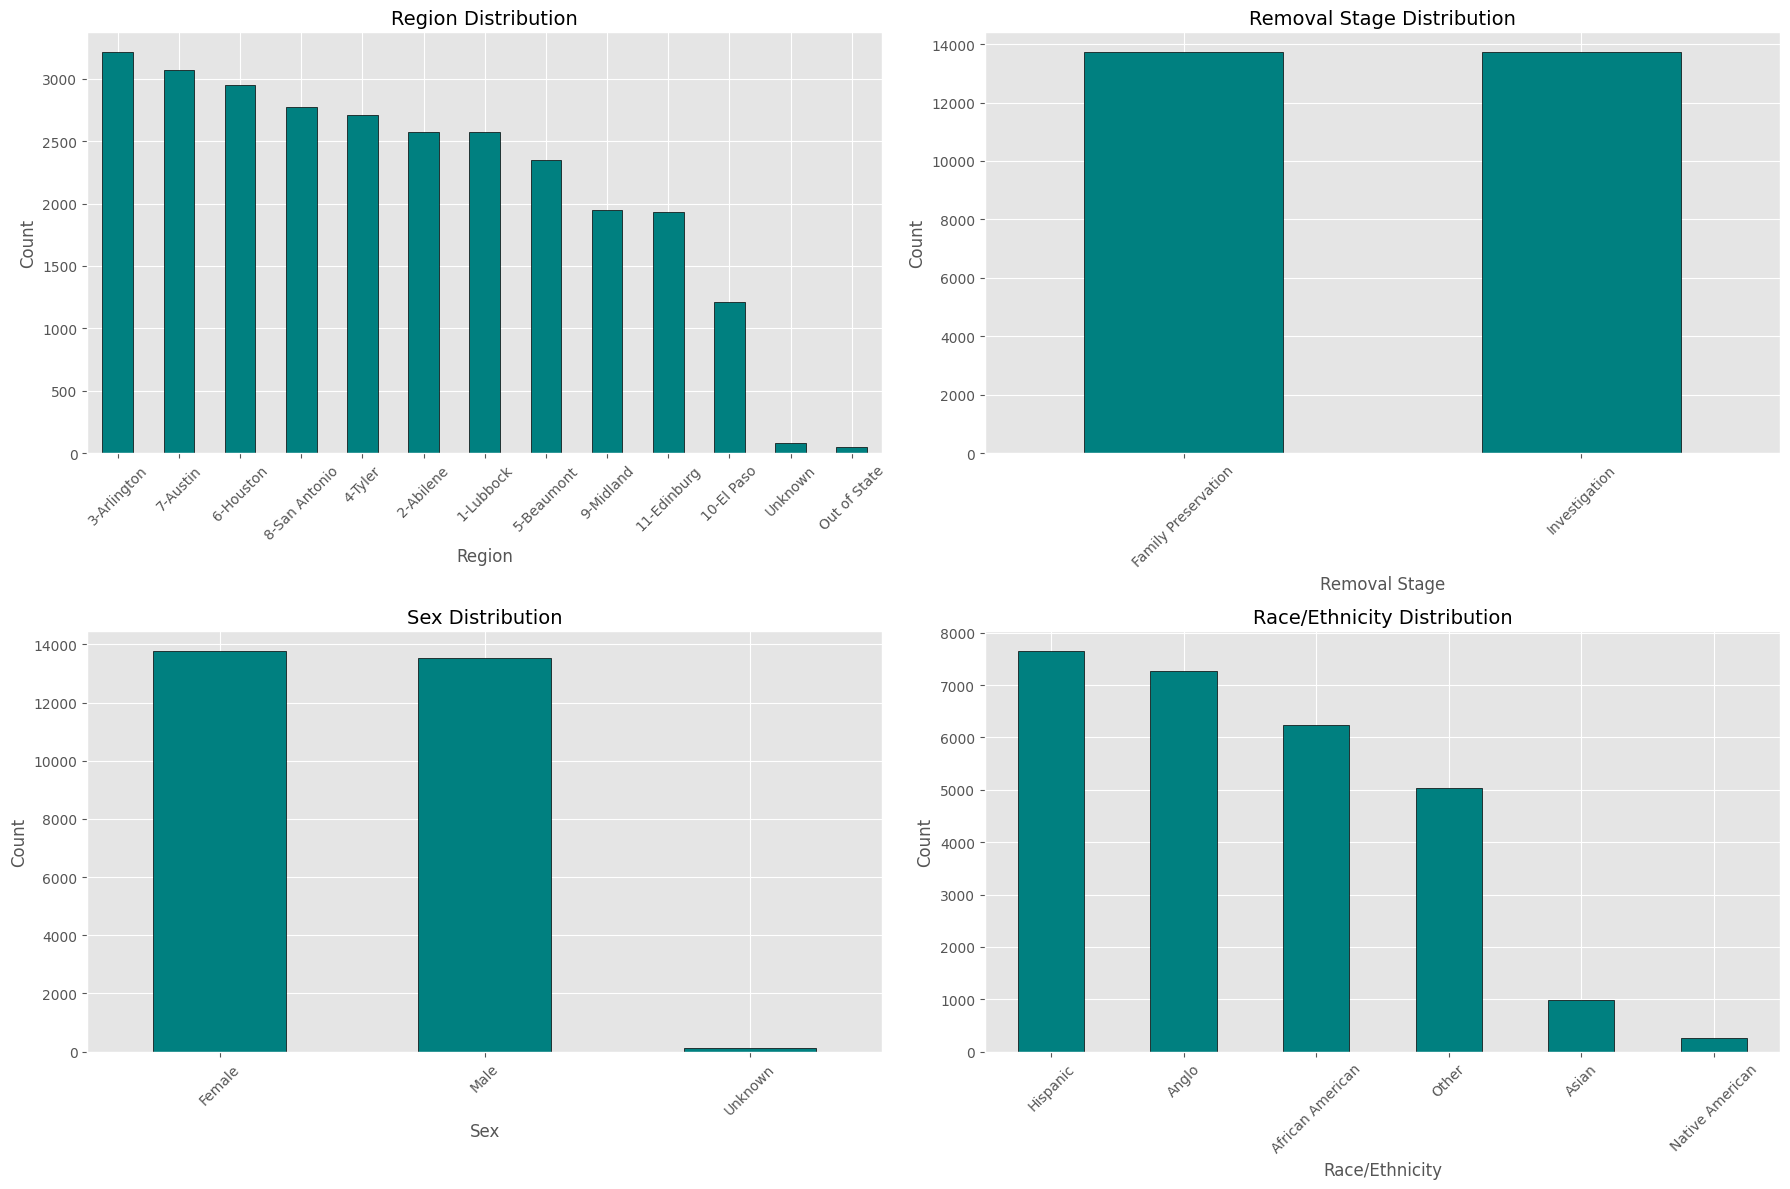

In [9]:
# Distribution of Region, Removal Stage, Sex, and Race/Ethnicity

categorical_cols = ['region', 'removal_stage', 'sex', 'race/ethnicity']

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    df[col].value_counts().plot(kind='bar', color='teal', edgecolor='black')
    plt.title(f'{col.replace("_", " ").title()} Distribution', fontsize=14)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Plotly interactive example
* This plotly interactive graph will be rendered static for the purpose of displaying it's contents on GitHub.

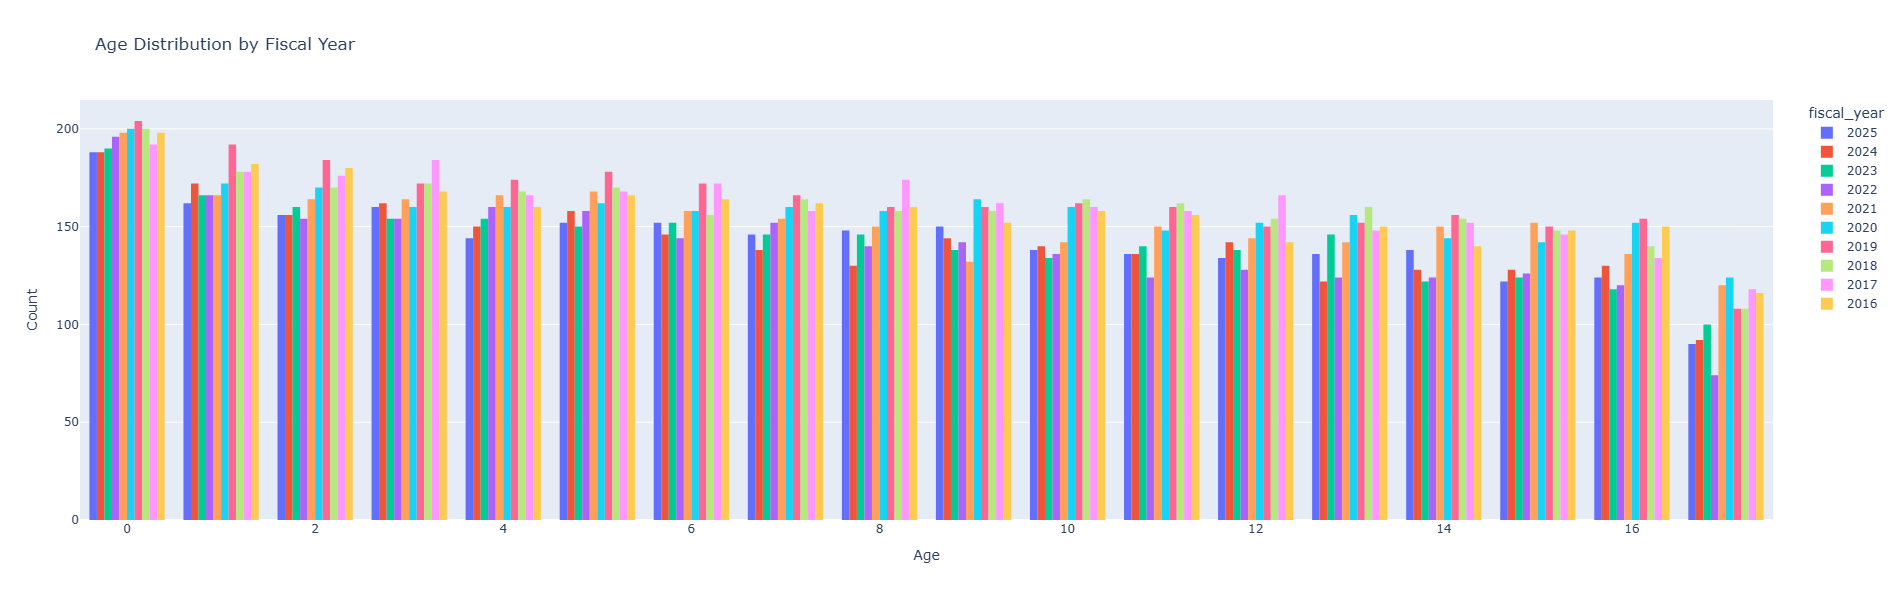

In [19]:
# Set the default renderer to PNG or SVG so it displays on GitHub

pio.renderers.default = "png" 

fig = px.histogram(df, x="age", color="fiscal_year", barmode="group", title="Age Distribution by Fiscal Year")  
fig.update_layout(xaxis_title="Age", 
                  yaxis_title="Count",
                  width=1900,
                  height=600,)
fig.show()

## Insights Summary

In [11]:
insights = """ Insights found during the EDA process:
- What trends did you find?
- What variables are important?
- What variables correlate with each other?
- Are there any outliers?
- What srategies can be used to clean the data?"""